In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
working_directory = "/Users/kemalinecik/git_nosync/sctram"

In [3]:
import sys
sys.path.append(working_directory)

import logging
import os
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
from sctram.generate.real import sc_norman_sciplex_cpa

sc.settings.verbosity = 3

In [4]:
from sctram.infer._dpt import DPTInference
from sctram.evaluate._pseudotime import PseudotimeValuesEvaluation
from sctram.input import read_dict

In [5]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, 'rb') as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [6]:
dataset_dir = "/Users/kemalinecik/git_nosync/sctram/__temp__/data"
adata_norman = sc_norman_sciplex_cpa(dataset_dir=dataset_dir)
adata_bms = adata_norman[["bms" in i.lower() or "vehicle" in i.lower() for i in adata_norman.obs["drug"]]]

# Input

In [7]:
ground_truth_trajectories = {
    "trajectory_1": [
        ('Vehicle_1.0', 'BMS_0.001'),
        ('BMS_0.001', 'BMS_0.005'),
        ('BMS_0.005', 'BMS_0.01'),
        ('BMS_0.01', 'BMS_0.05'),
        ('BMS_0.05', 'BMS_0.1'),
        ('BMS_0.1', 'BMS_0.5'),
        ('BMS_0.5', 'BMS_1.0'),
    ],
}
input_trajectories_all = read_dict(ground_truth_trajectories)
input_trajectories = input_trajectories_all.get_trajectory("trajectory_1", include_additional_nodes=False)

In [8]:
np.array(input_trajectories.nodes())

array(['Vehicle_1.0', 'BMS_0.001', 'BMS_0.005', 'BMS_0.01', 'BMS_0.05',
       'BMS_0.1', 'BMS_0.5', 'BMS_1.0'], dtype='<U11')

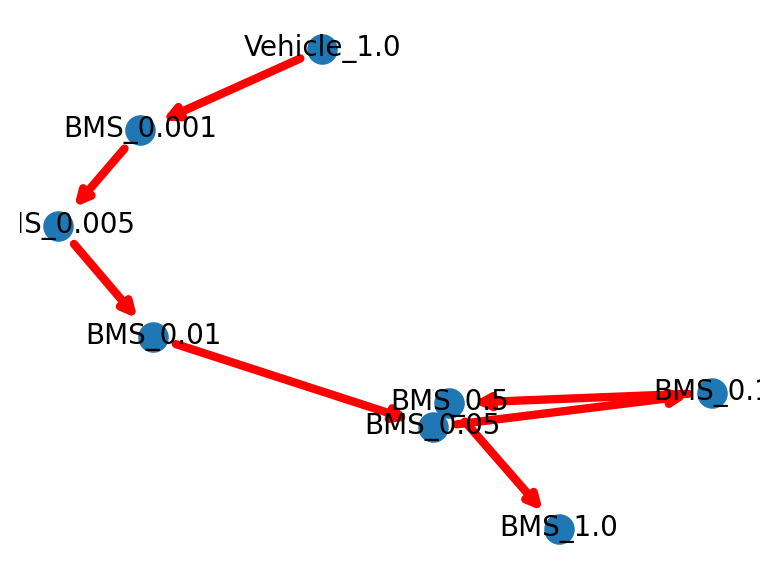

In [9]:
plt.figure(figsize=(4,3))
pos = nx.spring_layout(input_trajectories)  # positions for all nodes
nx.draw_networkx_nodes(input_trajectories, pos, node_size=100)
for u, v, data in input_trajectories.edges(data=True):
    nx.draw_networkx_edges(input_trajectories, pos, edgelist=[(u, v)], width=3, edge_color='red')
nx.draw_networkx_labels(input_trajectories, pos, font_size=10)
plt.axis("off")
plt.tight_layout()
plt.show()

# DPT

In [10]:
adata = ad.AnnData(X=adata_bms.obsm["tardis"].copy(), obs=adata_bms.obs.copy())

root_label = "Vehicle_1.0"

iroot_params = {
    "label_key": "labels",
    "label": root_label,
    "method": "min_diffmap",
    "outlier_definition_z": 3
}

dpt_inference = DPTInference(
    random_state=42, 
    neighbors_params={"n_neighbors": 90},
    iroot_params=iroot_params,
    adata=adata, 
    labels=adata.obs["drug_dose_name"]
)

dpt_inference.calculate()
# the same operation in the `infer` example notebook.

INFO:AnndataPreperation:No precomputed neighbors found in AnnData.
INFO:DPTInference:Starting DPTInference trajectory inference.
INFO:DPTInference:Performing trajectory inference.
INFO:DPTInference:Computing neighbors.


computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)


INFO:DPTInference:Computing Diffusion Map.


computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9957283  0.98897034 0.9752918  0.96000016 0.93977296
     0.9325454  0.9238255  0.90231395 0.8939387  0.89036936 0.88236076
     0.86557806 0.8639325  0.862859  ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)


INFO:DPTInference:Outlier removal applied. 2155 out of 2155 cells remain after filtering based on z-score <= 3.
INFO:DPTInference:Root set to cell index 2575 based on minimum in DiffMap component 0 within label 'Vehicle_1.0'.
INFO:DPTInference:Performing DPT trajectory calculation.


computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


INFO:DPTInference:Trajectory inference completed successfully.


In [11]:
inferred_trajectories = dpt_inference.get_result("vector")

In [12]:
pseudotime_evaluation = PseudotimeValuesEvaluation(
    method_params = dict(
            metrics = [
            "pearson",
            "spearman",
            "kendall",
            "mse",
            "mae",
            "r2",
            "concordance_index",
            "dynamic_time_warping",
            "wasserstein_distance",
            "mutual_information",
            "cumulative_density_difference",
            # New spatial metrics
            # "morans_i",
            # "gearys_c",
            # "local_morans_i",
            # "getis_ord_gi_star",
        ]
    ),
    prepare_params=dict(
        converter = dict(
            # method = "spectral",
            root_label = root_label
        )
    )
)

In [13]:
logging.getLogger().setLevel(logging.DEBUG)
try:
    pseudotime_evaluation.evaluate(
        given_trajectory=input_trajectories,
        inferred_trajectory=inferred_trajectories,
        labels=adata.obs["drug_dose_name"].to_numpy()
    )
finally:
    logging.getLogger().setLevel(logging.INFO)

INFO:PseudotimeValuesEvaluation:Starting evaluation with PseudotimeValuesEvaluation.
DEBUG:PseudotimeValuesEvaluation:Verifying given trajectory.
DEBUG:PseudotimeValuesEvaluation:Verifying inferred trajectory.
DEBUG:PseudotimeValuesEvaluation:Verifying labels.
DEBUG:PseudotimeValuesEvaluation:Checking the consistency between the given graph and labels.
DEBUG:PseudotimeValuesEvaluation:Preparing trajectories after subsetting.
DEBUG:PseudotimeValuesEvaluation:Converting `InputTrajectory` to adjacency matrix.
DEBUG:PseudotimeValuesEvaluation:Initializing `LabelAdjacencyPseudotimeConverter`.
DEBUG:PseudotimeValuesEvaluation:Computing reference pseudotime using method: diffusion_with_damping
DEBUG:PseudotimeValuesEvaluation:Computed label pseudotime successfully.
DEBUG:PseudotimeValuesEvaluation:Assigning pseudotime to cells based on label pseudotime.
DEBUG:PseudotimeValuesEvaluation:Normalizing reference and inferred pseudotime to [0, 1].
DEBUG:PseudotimeValuesEvaluation:Normalized pseudot

Diffusion pseudotime converged in 21 steps.


DEBUG:PseudotimeValuesEvaluation:Concordant pairs: 5417089
DEBUG:PseudotimeValuesEvaluation:Discordant pairs: 190320
DEBUG:PseudotimeValuesEvaluation:Usable pairs: 5607409
DEBUG:PseudotimeValuesEvaluation:Concordance Index: 0.9660591906172709
DEBUG:PseudotimeValuesEvaluation:Calculating metric: 'dynamic_time_warping'
ERROR:PseudotimeValuesEvaluation:DTW package is not installed. Dynamic Time Warping cannot be computed.
DEBUG:PseudotimeValuesEvaluation:Calculating metric: 'wasserstein_distance'
DEBUG:PseudotimeValuesEvaluation:Wasserstein distance: 0.1129031260820259
DEBUG:PseudotimeValuesEvaluation:Calculating metric: 'mutual_information'
DEBUG:PseudotimeValuesEvaluation:Mutual Information: 0.9113130506742306
DEBUG:PseudotimeValuesEvaluation:Calculating metric: 'cumulative_density_difference'
DEBUG:PseudotimeValuesEvaluation:Cumulative density difference (KS statistic): 0.5261358085002442, p-value: 0.0
INFO:PseudotimeValuesEvaluation:Evaluation completed successfully.


In [14]:
pseudotime_evaluation.get_result()

{'pearson': 0.9022949861402323,
 'pearson_p_value': 0.0,
 'spearman': 0.8681034142097269,
 'spearman_p_value': 0.0,
 'kendall': 0.7625571244858326,
 'kendall_p_value': 0.0,
 'mse': 0.03735907642195845,
 'mae': 0.13085564787533857,
 'r2': 0.7830202444641525,
 'concordance_index': 0.9660591906172709,
 'dynamic_time_warping': nan,
 'wasserstein_distance': 0.1129031260820259,
 'mutual_information': 0.9113130506742306,
 'cumulative_density_difference': 0.5261358085002442,
 'cumulative_density_p_value': 0.0}

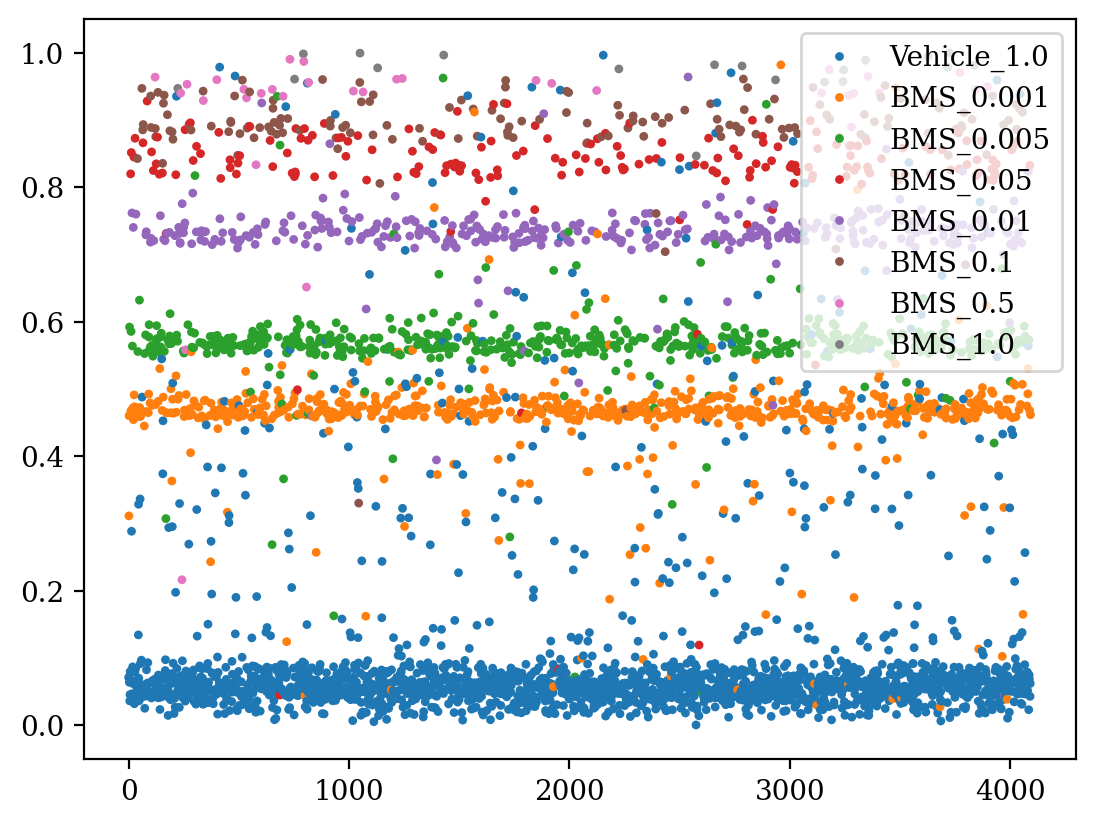

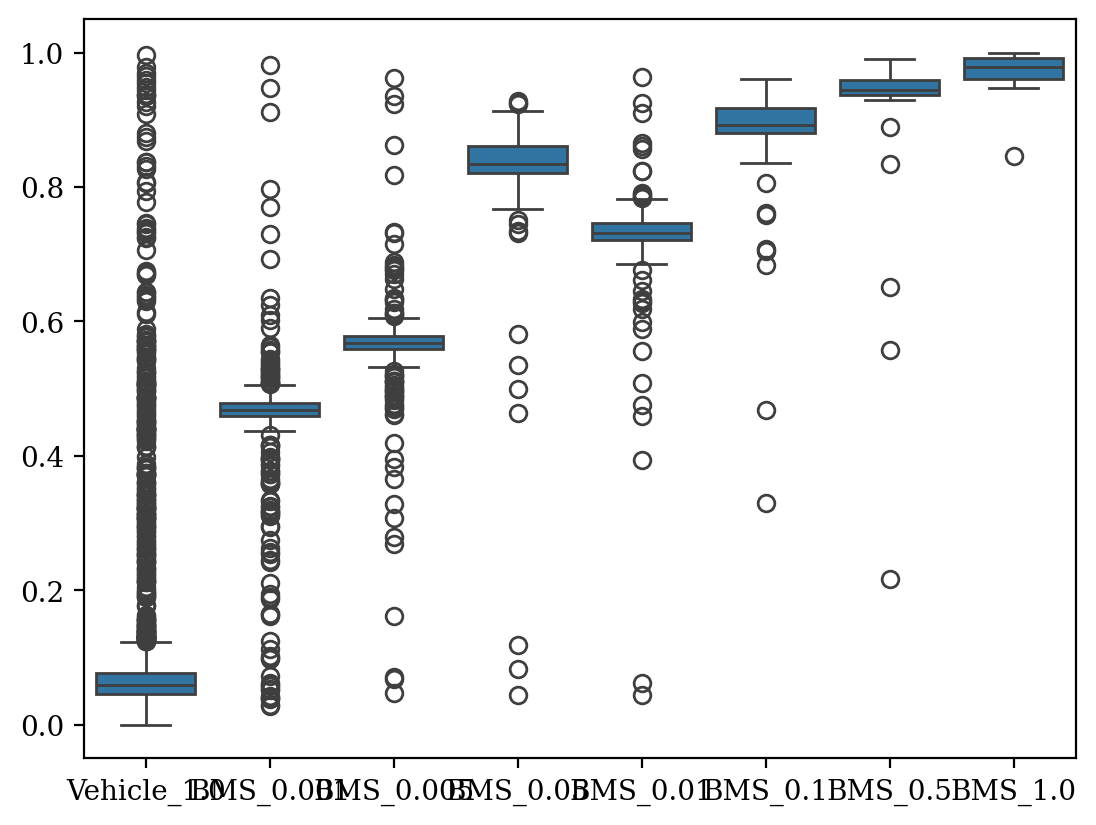

In [15]:
x = range(len(pseudotime_evaluation.prepared_after_subset_inferred))
y = pseudotime_evaluation.prepared_after_subset_inferred
hue = pseudotime_evaluation.subset_labels
sns.scatterplot(x=x, y=y, hue=hue, linewidth=0, s=10)
plt.show()
sns.boxplot(x=hue, y=y)
plt.show()

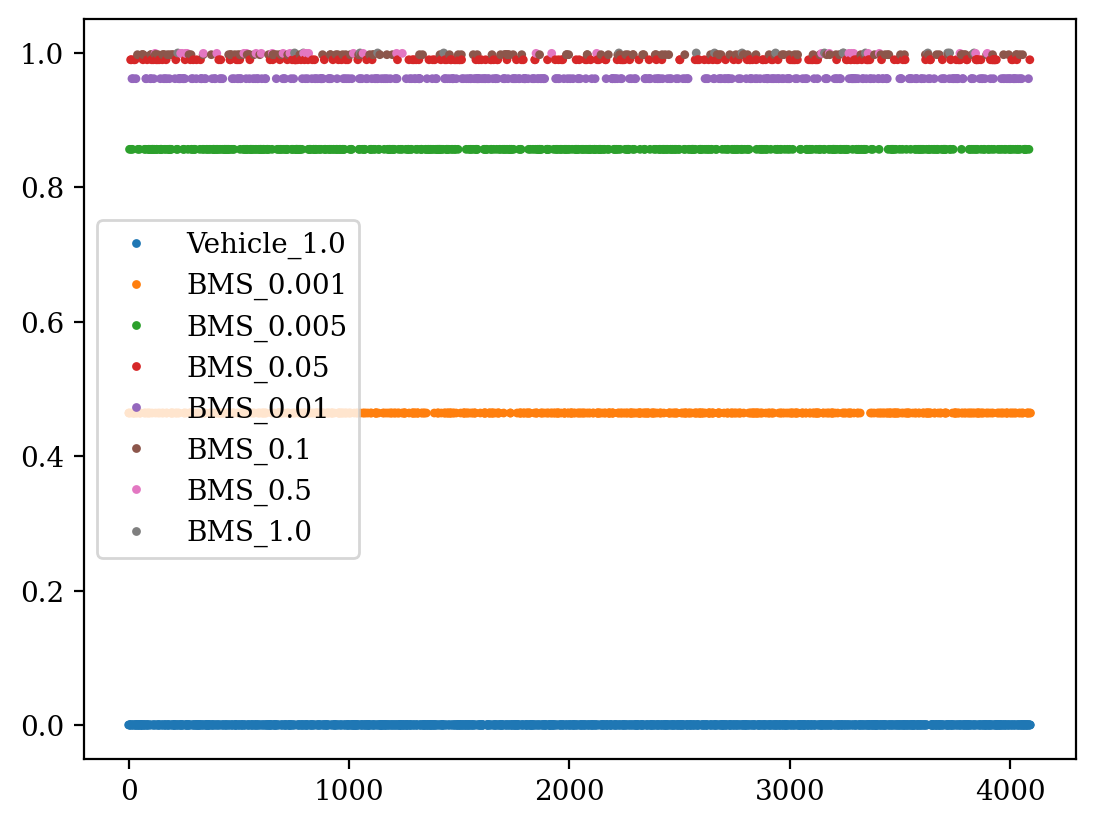

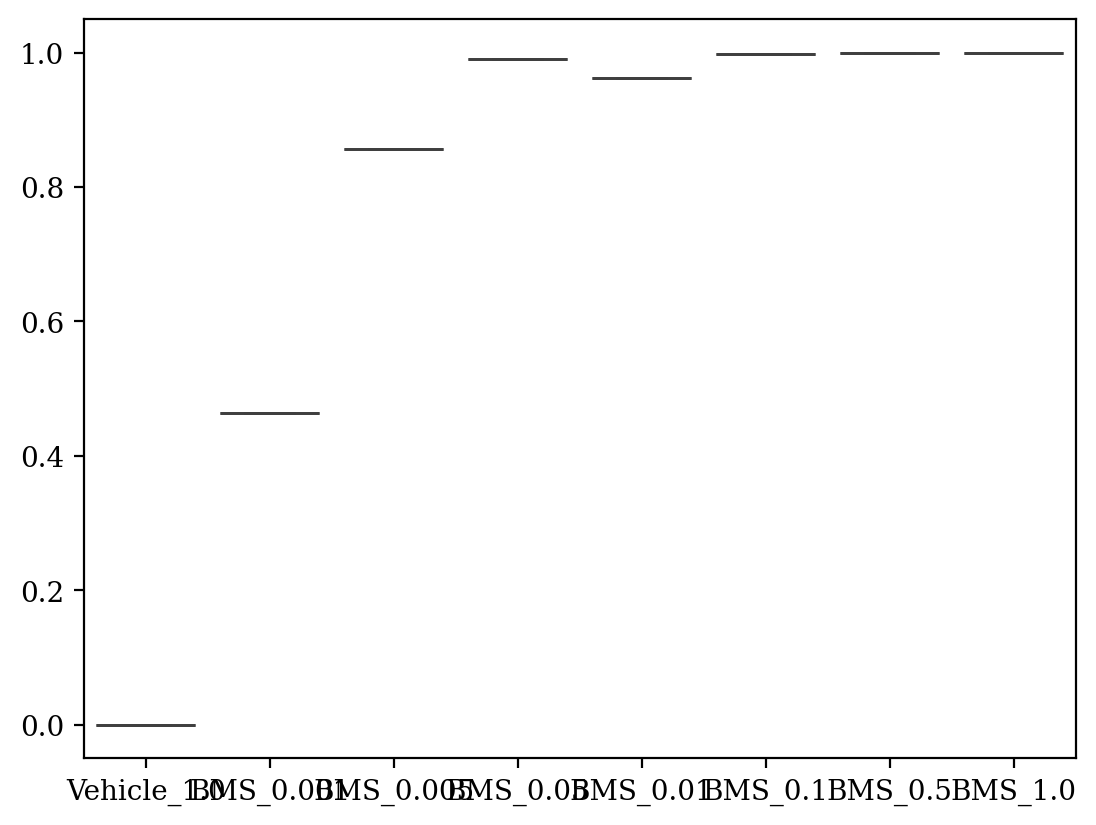

In [16]:
x = range(len(pseudotime_evaluation.prepared_after_subset_given))
y = pseudotime_evaluation.prepared_after_subset_given
hue = pseudotime_evaluation.subset_labels
sns.scatterplot(x=x, y=y, hue=hue, linewidth=0, s=10)
plt.show()
sns.boxplot(x=hue, y=y)
plt.show()

In [17]:
pd.DataFrame([y, hue]).T.groupby(by=1).mean()

,0
1,
BMS_0.001,0.464194
BMS_0.005,0.856576
BMS_0.01,0.961714
BMS_0.05,0.989883
BMS_0.1,0.997421
BMS_0.5,0.999405
BMS_1.0,1.0
Vehicle_1.0,0.0
